<a href="https://colab.research.google.com/github/damlattlcn/GES_Tespiti/blob/main/uydu_goruntulerinden_ges_tespiti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uydu Görüntülerinden GES Tespiti
## Attention U-Net + ResNet34 + DenseCRF


Bu çalışmada, uydu görüntülerinden Güneş Enerji Santrali (GES) bölgelerini doğru bir şekilde tespit etmek amacıyla **Attention U-Net ve ResNet34 encoder tabanlı derin öğrenme modeli** önerilmiştir.

## Veri Seti
"PV segmentation from satellite and aerial imagery" veri seti kullanılmıştır.

Uydu görüntüleri ve bunlara ait maske görüntülerinden oluşmaktadır.
Veri setinde GES bölgeleri piksel seviyesinde etiketlenmiştir.
Görüntüler eğitim ve test kümelerine ayrılarak model eğitimi gerçekleştirilmiştir.
Veri artırma teknikleri kullanılarak modelin genelleme başarısı artırılmıştır.
## Yöntem
1. Görüntüler belirlenen boyuta dönüştürülüp normalize edilir.
2. ResNet34 encoder ile derin özellikler çıkarılır.
3. Attention U-Net yapısı ile GES bölgeleri segmentasyon işlemiyle tespit edilir.
4.  Tahmin sonuçları Conditional Random Field (CRF) yöntemi ile iyileştirilir.
5. Model performansı **Dice Skoru** ve **IoU** metrikleri kullanılarak değerlendirilir.

## 1. Google Drive Bağlantısı ve Çalışma Dizini

Google Colab ortamı için Google Drive bağlanır ve veri setinin bulunduğu klasör çalışma dizini olarak ayarlanır. Farklı bir ortamda çalıştırıyorsanız bu adımı atlayabilirsiniz.

In [ ]:
# (1) Gerekli kurulumlar (Colab)
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick


## 2. Gerekli Kütüphanelerin Kurulumu

Projenin ihtiyaç duyduğu Python paketleri yüklenir:
- **segmentation-models-pytorch**: Hazır U-Net gibi segmentasyon modelleri
- **albumentations**: Veri artırma (augmentation) işlemleri
- **torchinfo**: Model mimarisini özetlemek için
- **pydensecrf**: Tahmin maskelerini iyileştirmek için Dense CRF uygulaması

In [ ]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.3.0 torchinfo pydensecrf

!pip install -q git+https://github.com/lucasb-eyer/pydensecrf.git

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 3. Kütüphane İmportları

Eğitim sürecinde kullanılacak tüm kütüphaneler aktarılır:
- `os`, `glob`, `random`: Dosya işlemleri ve rastgelelik
- `numpy`, `PIL`: Görüntü ve dizi işlemleri
- `torch`, `segmentation_models_pytorch`: Derin öğrenme ve U-Net model yapısı
- `albumentations`: Veri artırma
- `pydensecrf`: CRF tabanlı tahmin iyileştirme
- `sklearn`: Eğitim/doğrulama veri bölme

In [ ]:
# (2) Kütüphaneler
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

import pydensecrf.densecrf as dcrf
from sklearn.model_selection import train_test_split
from torchinfo import summary

## 4. Tekrarlanabilirlik (Seed) Ayarı

Deneylerin tekrarlanabilir olması için rastgelelik tohumları sabitlenir. `seed=42` ile Python, NumPy ve PyTorch'un rastgele sayı üreteçleri aynı başlangıç noktasına ayarlanır.

In [ ]:
# Set reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

## 5. GES Veri Seti Sınıfı (GESDataset)

PyTorch `Dataset` sınıfından türetilen özel veri seti tanımlanır:
- Görüntü ve maske dosya yollarını alır
- Her örnek için görüntüyü RGB, maskeyi gri tonlamalı olarak okur
- Maskeyi ikili (binary) formata dönüştürür (piksel > 0.5 → 1, aksi → 0)
- Albumentations dönüşümlerini uygular
- Maske boyutunu modele uygun formata getirir (H×W → 1×H×W)

In [ ]:
class GESDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):   # <-- Burada girintiye dikkat et
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"), dtype=np.float32) / 255.0
        mask = np.where(mask > 0.5, 1.0, 0.0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]
        else:
            img = ToTensorV2()(image=img)["image"]
            mask = torch.from_numpy(mask)

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img, mask



## 6. Dosya Yolları ve Görüntü-Maske Eşleştirme

Görüntü ve maske klasörleri tanımlanır. Bazı veri setlerinde maskeler `_label` eki taşıyabileceğinden bu durum normalize edilir. Yalnızca karşılıklı maske dosyası bulunan görüntüler kullanılır.

In [ ]:
# (4) Dosya yolları - kendi drive yapına göre düzenle
IMAGE_DIR = "/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/images"
MASK_DIR  = "/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/masks"

# normalize file lists and match (örnek mask isimleri: imgname_label.png veya imgname.png)
image_files = sorted([os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.bmp','.png','.jpg','.jpeg'))])
mask_files_all = sorted([f for f in os.listdir(MASK_DIR) if f.lower().endswith(('.png','.bmp'))])

# Create mapping from base name -> mask path
mask_map = {}
for m in mask_files_all:
    base = os.path.splitext(m)[0].replace("_label","")
    mask_map[base] = os.path.join(MASK_DIR, m)

# Keep only images that have masks
images = []
masks  = []
for img_path in image_files:
    base = os.path.splitext(os.path.basename(img_path))[0]
    if base in mask_map:
        images.append(img_path)
        masks.append(mask_map[base])

print(f"Found {len(images)} paired image-mask samples.")

Found 138 paired image-mask samples.


## 7. Eğitim / Doğrulama Veri Bölme

 Veri seti **%80 eğitim** ve **%20 doğrulama** olarak ayrılır. `random_state=seed` ile bölme deterministik hale getirilir.

In [ ]:
# (5) Train/Val split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(images, masks, test_size=0.20, random_state=seed)
print("Train:", len(train_imgs), "Val:", len(val_imgs))

Train: 110 Val: 28


## 8. Veri Artırma (Augmentation) ve DataLoader Oluşturma

Eğitim için zengin bir augmentation pipeline tanımlanır:
- Rastgele döndürme, yansıtma, kaydırma, ölçekleme
- Parlaklık/kontrast, renk tonu, bulanıklık, gürültü ekleme
- 256×256 yeniden boyutlandırma ve ImageNet normalizasyonu

Doğrulama için yalnızca boyutlandırma ve normalizasyon uygulanır. Her iki set için `DataLoader` oluşturulur (batch_size=4).

In [ ]:
# (6) Augmentations
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.Flip(p=0.5),
    A.Transpose(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=25, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.MotionBlur(p=0.2),
    A.GaussNoise(p=0.2),
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256,256),
    A.Normalize(),
    ToTensorV2()
])

train_dataset = GESDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = GESDataset(val_imgs, val_masks, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

## 9. Model Tanımı: Attention U-Net (ResNet34 Encoder)

**segmentation_models_pytorch** ile U-Net modeli oluşturulur:
- **Encoder**: ImageNet önceden eğitimli ResNet34
- **Decoder dikkat mekanizması**: scSE (Spatial and Channel Squeeze & Excitation)
- **Giriş**: 3 kanallı (RGB) görüntüler, **Çıkış**: 1 kanallı segmentasyon maskesi

Model CUDA varsa GPU'ya, yoksa CPU'ya taşınır.

In [ ]:
# (7) Model - Attention U-Net + resnet34 encoder (smp Unet, scse attention)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
model.to(device)
summary(model, input_size=(1,3,256,256))

Layer (type:depth-idx)                                       Output Shape              Param #
Unet                                                         [1, 1, 256, 256]          --
├─ResNetEncoder: 1-1                                         [1, 3, 256, 256]          --
│    └─Conv2d: 2-1                                           [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                                      [1, 64, 128, 128]         128
│    └─ReLU: 2-3                                             [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                                        [1, 64, 64, 64]           --
│    └─Sequential: 2-5                                       [1, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                                  [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                                  [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                                  [1, 64, 64, 64]       

## 10. Kayıp Fonksiyonu, Optimizer ve Öğrenme Hızı Zamanlayıcısı

**BCEDiceLoss** özel kayıp fonksiyonu: Binary Cross-Entropy ve Dice kaybının toplamı.
- **BCE**: Piksel başına ikili sınıflandırma kaybı
- **Dice**: Örtüşme oranını optimize eder, sınıf dengesizliğine dirençlidir

**Adam** optimizer (lr=1e-4) ve **CosineAnnealingLR** zamanlayıcısı kullanılır.

In [ ]:
# (8) Loss, optimizer, scheduler
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)
        preds_sig = torch.sigmoid(preds)
        smooth = 1e-6
        intersection = (preds_sig * targets).sum(dim=(2,3))
        dice_loss = 1 - (2.*intersection + smooth) / (preds_sig.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)
        dice_loss = dice_loss.mean()
        return bce_loss + dice_loss

loss_fn = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

## 11. Değerlendirme Metrikleri: IoU ve Dice

Modelin segmentasyon başarısını ölçmek için iki metrik fonksiyonu:
- **IoU (Intersection over Union)**: Tahmin ve gerçek maskenin kesişiminin birleşime oranı
- **Dice Skoru**: Tahmin ile gerçek arasındaki örtüşmenin harmonik ortalaması

Her iki metrik de 0.5 eşiğiyle ikili maske üretip karşılaştırma yapar.

In [ ]:
# (9) Metrics: IoU & Dice
def iou_score(preds, targets, thr=0.5, eps=1e-6):
    preds = (preds>thr).astype(np.uint8)
    targets = targets.astype(np.uint8)
    intersection = (preds & targets).sum()
    union = (preds | targets).sum()
    return (intersection + eps) / (union + eps)

def dice_score(preds, targets, thr=0.5, eps=1e-6):
    preds = (preds>thr).astype(np.uint8)
    targets = targets.astype(np.uint8)
    inter = (preds & targets).sum()
    return (2*inter + eps) / (preds.sum() + targets.sum() + eps)

## 12. Dense CRF Fonksiyonu (Tahmin İyileştirme)

**DenseCRF**, modelin olasılık çıktısını iyileştirmek için kullanılır:
- Model olasılık haritasını unary enerji olarak alır
- Gaussian ve bilateral pairwise potansiyeller ekler
- 5 iterasyon çıkarım yaparak kenar bilgisine duyarlı, daha temiz maske üretir

In [ ]:
# (10) CRF function (inference-time)
def apply_crf(image, mask_prob):
    """
    image: HxWx3 uint8
    mask_prob: HxW float [0..1]
    returns: HxW {0,1}
    """
    H, W = image.shape[:2]
    # unary: shape (2, H*W)
    mask_prob = np.clip(mask_prob, 1e-6, 1-1e-6)
    unary = np.stack([1-mask_prob, mask_prob], axis=0)
    unary = -np.log(unary)
    unary = unary.reshape((2, -1)).astype(np.float32)
    d = dcrf.DenseCRF2D(W, H, 2)
    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=3, compat=3)
    d.addPairwiseBilateral(sxy=60, srgb=13, rgbim=image, compat=10)
    Q = d.inference(5)
    res = np.argmax(Q, axis=0).reshape((H,W)).astype(np.uint8)
    return res

## 13. Eğitim ve Doğrulama Döngüsü (Early Stopping ile)

Ana eğitim döngüsü:
- **Eğitim**: İleri/geri yayılım, kayıp hesaplama, parametre güncelleme
- **Doğrulama**: Val seti üzerinde kayıp, IoU ve Dice hesaplama
- **Early Stopping**: Val IoU `patience=10` epoch boyunca iyileşmezse eğitim durur
- En iyi model ağırlıkları `best_attention_unet_resnet34.pth` olarak kaydedilir

In [ ]:
# (11) Train / Val loops with EarlyStopping
best_iou = 0.0
patience = 10
counter = 0
num_epochs = 40
accumulation_steps = 1  # increase if want gradient accumulation

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for i, (imgs, masks_) in enumerate(train_loader):
        imgs = imgs.to(device, dtype=torch.float32)
        masks_ = masks_.to(device, dtype=torch.float32)

        preds = model(imgs)
        loss = loss_fn(preds, masks_)/accumulation_steps
        loss.backward()

        if (i+1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        train_loss += loss.item()*accumulation_steps

    scheduler.step()

    # validation
    model.eval()
    val_losses = []
    ious = []
    dices = []
    with torch.no_grad():
        for imgs, masks_ in val_loader:
            imgs = imgs.to(device, dtype=torch.float32)
            masks_ = masks_.to(device, dtype=torch.float32)

            preds = model(imgs)
            loss = loss_fn(preds, masks_)
            val_losses.append(loss.item())

            probs = torch.sigmoid(preds).cpu().numpy()
            imgs_np = imgs.cpu().numpy()
            for b in range(probs.shape[0]):
                prob = probs[b,0]
                img_np = (np.transpose(imgs_np[b], (1,2,0)) * 255).astype(np.uint8)
                true_mask = masks_[b,0].cpu().numpy()
                # plain threshold metric
                iou_plain = iou_score((prob>0.5).astype(np.uint8), true_mask.astype(np.uint8))
                dice_plain = dice_score((prob>0.5).astype(np.uint8), true_mask.astype(np.uint8))
                ious.append(iou_plain)
                dices.append(dice_plain)

    mean_val_loss = np.mean(val_losses)
    mean_iou = np.mean(ious) if len(ious)>0 else 0
    mean_dice = np.mean(dices) if len(dices)>0 else 0

    print(f"Epoch {epoch+1}/{num_epochs}  train_loss={train_loss/len(train_loader):.4f}  val_loss={mean_val_loss:.4f}  val_iou={mean_iou:.4f}  val_dice={mean_dice:.4f}")

    # EarlyStopping on val_iou
    if mean_iou > best_iou + 1e-5:
        best_iou = mean_iou
        counter = 0
        torch.save(model.state_dict(), "best_attention_unet_resnet34.pth")
        print("  -> New best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/40  train_loss=1.3433  val_loss=1.3237  val_iou=0.1629  val_dice=0.2614
  -> New best model saved.
Epoch 2/40  train_loss=1.2037  val_loss=1.1464  val_iou=0.3931  val_dice=0.5176
  -> New best model saved.
Epoch 3/40  train_loss=1.0782  val_loss=0.9558  val_iou=0.4751  val_dice=0.5921
  -> New best model saved.
Epoch 4/40  train_loss=0.9635  val_loss=0.8591  val_iou=0.6048  val_dice=0.7037
  -> New best model saved.
Epoch 5/40  train_loss=0.8881  val_loss=0.8020  val_iou=0.6097  val_dice=0.7085
  -> New best model saved.
Epoch 6/40  train_loss=0.8431  val_loss=0.7399  val_iou=0.6478  val_dice=0.7362
  -> New best model saved.
Epoch 7/40  train_loss=0.8115  val_loss=0.7030  val_iou=0.6379  val_dice=0.7294
Epoch 8/40  train_loss=0.7732  val_loss=0.7007  val_iou=0.6685  val_dice=0.7505
  -> New best model saved.
Epoch 9/40  train_loss=0.7542  val_loss=0.6844  val_iou=0.6787  val_dice=0.7615
  -> New best model saved.
Epoch 10/40  train_loss=0.7577  val_loss=0.6828  val_iou=0.6786 

## 14. Çıkarım Örneği: CRF ile Görselleştirme

En iyi model yüklenerek bir doğrulama örneği üzerinde tahmin yapılır. Girdi görüntü, ham model tahmini ve CRF sonrası maske yan yana görselleştirilir.

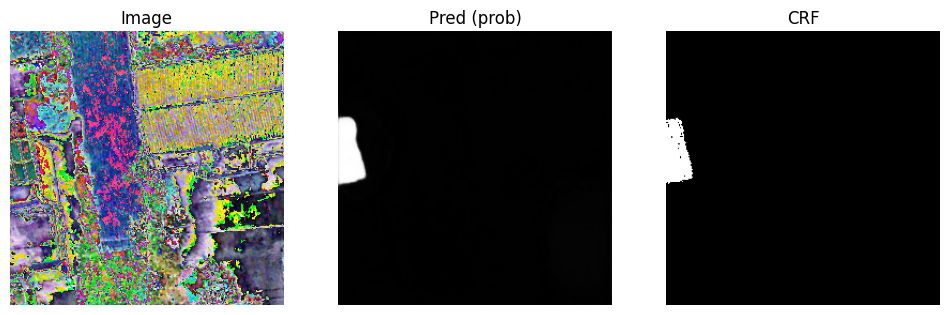

In [ ]:
# (12) Inference example with CRF and visualize
model.load_state_dict(torch.load("best_attention_unet_resnet34.pth", map_location=device))
model.eval()
with torch.no_grad():
    sample_img, sample_mask = val_dataset[0]
    inp = sample_img.unsqueeze(0).to(device)
    pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()
    img_rgb = (np.transpose(sample_img.numpy(), (1,2,0)) * 255).astype(np.uint8)

    crf_out = apply_crf(img_rgb, pred)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_rgb); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Pred (prob)"); plt.imshow(pred, cmap="gray"); plt.axis("off")
    plt.subplot(1,3,3); plt.title("CRF"); plt.imshow(crf_out, cmap="gray"); plt.axis("off")
    plt.show()




## TEST KISMI

## 15. Test Ortamı Kurulumu

Test için sistem bağımlılıkları ve Python paketleri yüklenir. `pydensecrf` C++ Eigen kütüphanesiyle kaynaktan derlenir. PyTorch, CUDA 12.1 için belirtilen sürüm yüklenir.

In [ ]:
!apt-get update
!apt-get install -y build-essential libeigen3-dev
!pip install git+https://github.com/lucasb-eyer/pydensecrf.git
!pip install segmentation-models-pytorch albumentations torchinfo
!pip install torch==2.4.0 torchvision==0.19.0 --index-url https://download.pytorch.org/whl/cu121
!pip install segmentation-models-pytorch --quiet

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,923 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [32.9 kB]
Get:13 https://ppa.la

## 16. Test Kütüphane İmportları

Test aşamasında kullanılacak kütüphaneler aktarılır. Eğitime ek olarak:
- `cv2 (OpenCV)`: Görüntü işleme
- `sklearn.metrics`: Jaccard, Precision, Recall, Accuracy
- `pydensecrf.utils.unary_from_softmax`: CRF için unary enerji dönüşümü

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import jaccard_score, precision_score, recall_score, accuracy_score
import segmentation_models_pytorch as smp
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax

## 17. Test Dönüşümleri

Test/çıkarım aşamasında yalnızca boyutlandırma ve normalizasyon uygulanır. Veri artırma kullanılmaz — gerçek performans ölçümü için bu gereklidir.

In [ ]:
# Test transform
test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])


## 18. Dataset Sınıfları (Test için)

İki dataset sınıfı:
- **GESDataset**: Görüntü + gerçek maske içeren örnekler için (değerlendirme)
- **GESDatasetNoMask**: Yalnızca görüntü içeren örnekler için (maske olmadan çıkarım)

In [ ]:
# Dataset sınıfları
class GESDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]
        else:
            img, mask = ToTensorV2()(image=img)["image"], ToTensorV2()(image=mask)["image"]
        return img, mask.float()

class GESDatasetNoMask(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img


## 19. IoU ve Dice Metrik Fonksiyonları (Test Versiyonu)

Sklearn tabanlı test metrikleri. `jaccard_score` ile IoU hesaplanır. Piksel bazında karşılaştırma yapılır.

In [ ]:
# IoU ve Dice fonksiyonları
def iou_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).astype(np.uint8).flatten()
    target_bin = (target > threshold).astype(np.uint8).flatten()
    return jaccard_score(target_bin, pred_bin)

def dice_score(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).astype(np.uint8).flatten()
    target_bin = (target > threshold).astype(np.uint8).flatten()
    intersection = np.sum(pred_bin * target_bin)
    return 2 * intersection / (np.sum(pred_bin) + np.sum(target_bin) + 1e-6)

## 20. CRF Fonksiyonu (Test Versiyonu)

`unary_from_softmax` kullanılarak standart CRF uygulaması. Softmax çıktısından unary enerji türetilir, `n_iter` iterasyon çıkarım yapılır.

In [ ]:
# CRF fonksiyonu
def apply_crf(image, mask_prob, n_iter=5):
    h, w = image.shape[:2]
    d = dcrf.DenseCRF2D(w, h, 2)
    mask_softmax = np.stack([1 - mask_prob, mask_prob], axis=0)
    unary = unary_from_softmax(mask_softmax)
    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=3, compat=3)
    d.addPairwiseBilateral(sxy=50, srgb=13, rgbim=image, compat=10)
    q = d.inference(n_iter)
    return np.array(q)[1].reshape((h, w))

## 21. Test Klasör Yolları

Test görüntüleri ve maskeleri için Drive dizin yolları tanımlanır. Desteklenen uzantılar filtrelenerek dosya listeleri oluşturulur.

In [ ]:
# Klasör yolları
test_image_dir = "/content/drive/MyDrive/GES_veriseti/test/images"
test_mask_dir = "/content/drive/MyDrive/GES_veriseti/test/masks"

test_image_paths = [os.path.join(test_image_dir, f) for f in sorted(os.listdir(test_image_dir)) if f.lower().endswith(('.png', '.jpg', '.bmp'))]
test_mask_paths = [os.path.join(test_mask_dir, f) for f in sorted(os.listdir(test_mask_dir)) if f.lower().endswith('.png')]

## 22. Test Dataset ve DataLoader

Test verisi için dataset ve loader oluşturulur. `batch_size=1` — CRF adımı görüntü bazında çalıştığından tek tek işlenir.

In [ ]:
# Test dataset ve loader
test_dataset = GESDataset(test_image_paths, test_mask_paths, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## 23. Eğitilmiş Modelin Yüklenmesi

En iyi model ağırlıkları yüklenir. `model.eval()` ile Dropout ve BatchNorm katmanları çıkarım moduna alınır.

In [ ]:
# Model yükleme
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"
)
model.load_state_dict(torch.load("/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/best_attention_unet_resnet34.pth", map_location="cpu"))
model.to(device)
model.eval()

/tmp/ipython-input-1228537451.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/b

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## 24. Test Döngüsü: IoU ve Dice Hesaplama

Her test görüntüsü için:
1. Model sigmoid çıktısı (olasılık haritası) hesaplanır
2. CRF uygulanarak maske iyileştirilir
3. CRF çıktısı ile gerçek maske arasında IoU ve Dice hesaplanır

In [ ]:
# Test döngüsü
ious, dices = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = torch.sigmoid(model(imgs))
        preds_np = preds.squeeze().cpu().numpy()
        imgs_np = imgs.squeeze().permute(1, 2, 0).cpu().numpy()
        masks_np = masks.squeeze().cpu().numpy()
        # Ensure imgs_np is C-contiguous before passing to apply_crf
        crf_mask = apply_crf(np.ascontiguousarray((imgs_np * 255).astype(np.uint8)), preds_np)
        ious.append(iou_score(crf_mask, masks_np))
        dices.append(dice_score(crf_mask, masks_np))

## 25. Test Sonuçlarının Görselleştirilmesi

Her test görüntüsü için üç panel: **girdi görüntü**, **model tahmini**, **CRF sonrası maske**. Döngü sonunda ortalama IoU ve Dice ekrana yazdırılır.

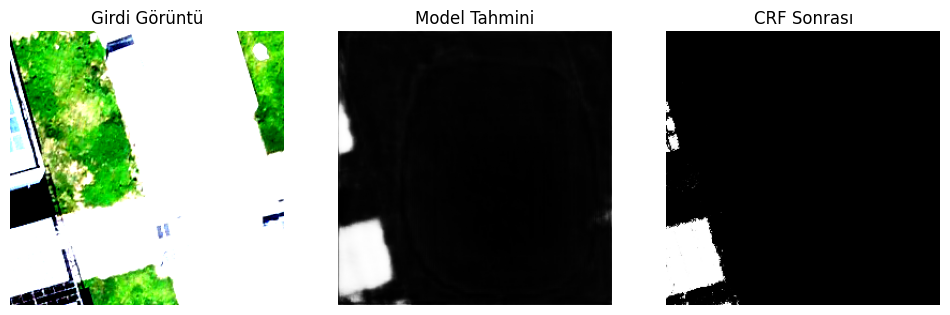

Ortalama IoU: 0.9541
Ortalama Dice: 0.9761


In [ ]:
        # Görselleştirme
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(imgs_np)
        plt.title("Girdi Görüntü")
        plt.axis('off')

        plt.subplot(1,3,2)
        plt.imshow(preds_np, cmap='gray')
        plt.title("Model Tahmini")
        plt.axis('off')

        plt.subplot(1,3,3)
        plt.imshow(crf_mask, cmap='gray')
        plt.title("CRF Sonrası")
        plt.axis('off')
        plt.show()

print(f"Ortalama IoU: {np.mean(ious):.4f}")
print(f"Ortalama Dice: {np.mean(dices):.4f}")

## 26. Precision, Recall ve Accuracy

0.5 eşiğiyle piksel bazlı sınıflandırma metrikleri:
- **Precision**: Pozitif tahminlerin ne kadarı gerçekten pozitif
- **Recall**: Gerçek pozitiflerin ne kadarı yakalandı
- **Accuracy**: Toplam doğru sınıflandırma oranı

In [ ]:
# Precision, Recall, Accuracy
all_preds, all_masks = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        masks = (masks > 0).float()
        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_masks.append(masks.cpu().numpy().reshape(-1))

all_preds = np.concatenate(all_preds)
all_masks = np.concatenate(all_masks)
print(f"Precision: {precision_score(all_masks, all_preds):.4f}")
print(f"Recall: {recall_score(all_masks, all_preds):.4f}")
print(f"Accuracy: {accuracy_score(all_masks, all_preds):.4f}")

Precision: 0.9902
Recall: 0.9783
Accuracy: 0.9829


## 27. Tek Görüntü Üzerinde Çıkarım (Maskesiz)

Gerçek maskesi olmayan tek bir görüntü üzerinde model çalıştırılır. Girdi ve model tahmini yan yana görselleştirilir.

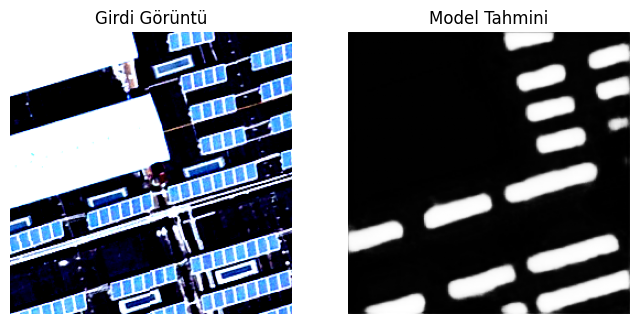

In [ ]:
# Tek görüntü deneme
test_img_path = "/content/drive/MyDrive/GES_veriseti/deneme/PV01_325195_1204167.bmp"
no_mask_dataset = GESDatasetNoMask([test_img_path], transform=test_transform)
no_mask_loader = DataLoader(no_mask_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    for imgs in no_mask_loader:
        imgs = imgs.to(device)
        preds_np = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(imgs.squeeze().permute(1,2,0).cpu().numpy())
        plt.title("Girdi Görüntü")
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.imshow(preds_np, cmap='gray')
        plt.title("Model Tahmini")
        plt.axis('off')
        plt.show()

## 28. Toplu Tahmin Kaydetme

Klasördeki tüm görüntüler için:
1. Model çıktısına CRF uygulanır
2. Görüntü denormalize edilerek orijinal renge döndürülür
3. Üçlü panel (girdi, tahmin, CRF) olarak `sonuclar2` klasörüne kaydedilir

In [ ]:
# Tüm görseller için tahmin kaydetme
test_dir = "/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/images"
save_dir = "/content/drive/MyDrive/GES_veriseti/sonuclar2"
os.makedirs(save_dir, exist_ok=True)
image_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]
no_mask_dataset = GESDatasetNoMask(image_paths, transform=test_transform)
no_mask_loader = DataLoader(no_mask_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    for img_path, imgs in zip(image_paths, no_mask_loader):
        imgs = imgs.to(device)
        preds_np = torch.sigmoid(model(imgs)).squeeze().cpu().numpy()
        orig_img = np.array(Image.open(img_path).convert("RGB"))
        crf_result = apply_crf(orig_img, preds_np)

        # Visualization code from the erroneous cell
        plt.figure(figsize=(12, 4))
        img_np = imgs.squeeze().permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = np.clip(std * img_np + mean, 0, 1)
        plt.subplot(1, 3, 1)
        plt.imshow(img_np)
        plt.title("Girdi Görüntü")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(preds_np, cmap='gray')
        plt.title("Model Tahmini")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(crf_result, cmap='gray')
        plt.title("CRF Sonrası")
        plt.axis('off')

        save_path = os.path.join(save_dir, os.path.basename(img_path).rsplit(".", 1)[0] + "_sonuc.png")
        plt.savefig(save_path, dpi=300)
        plt.close()

print(f"Tüm sonuçlar {save_dir} klasörüne kaydedildi.")

Tüm sonuçlar /content/drive/MyDrive/GES_veriseti/sonuclar2 klasörüne kaydedildi.


**Sonuçlar2 klasörüne kaydedilen verilerin bazılarını aşağı ekledim.**

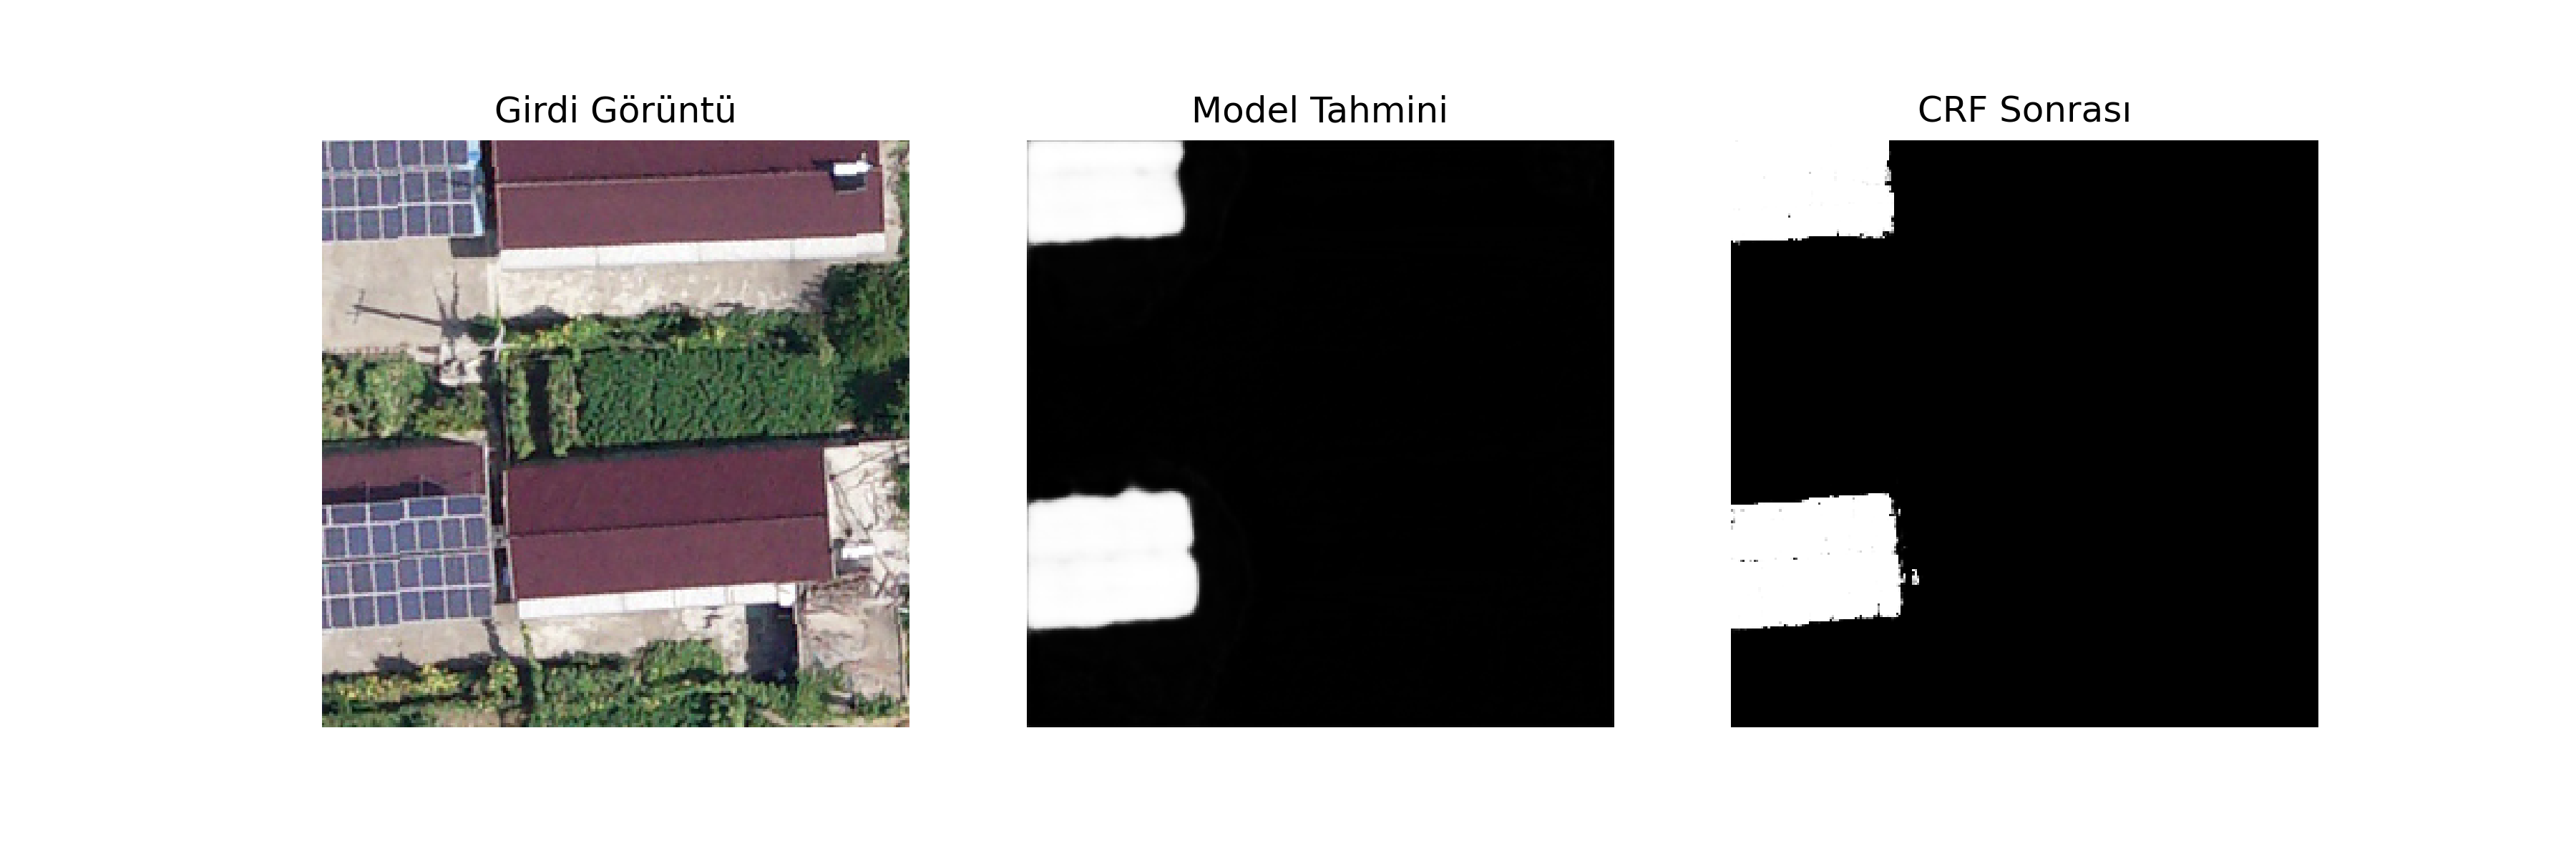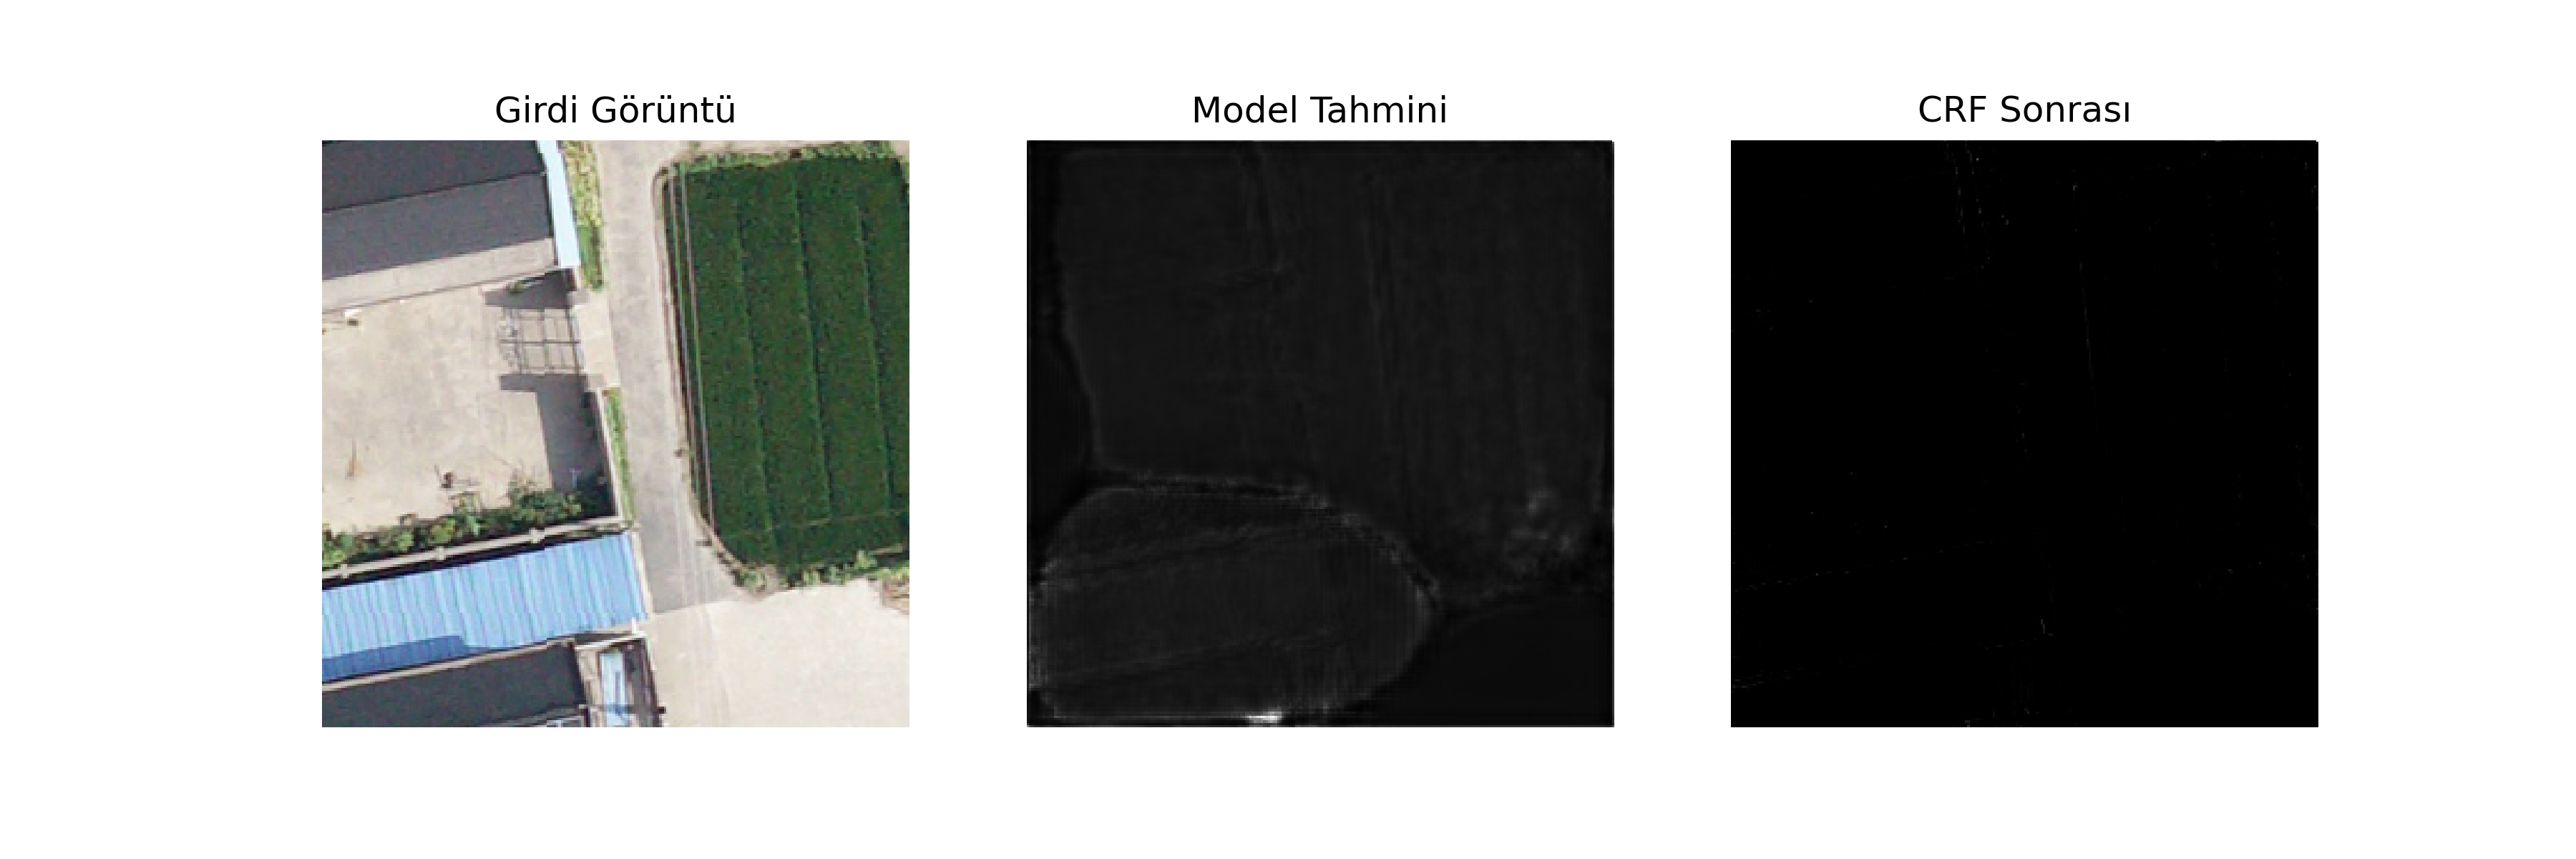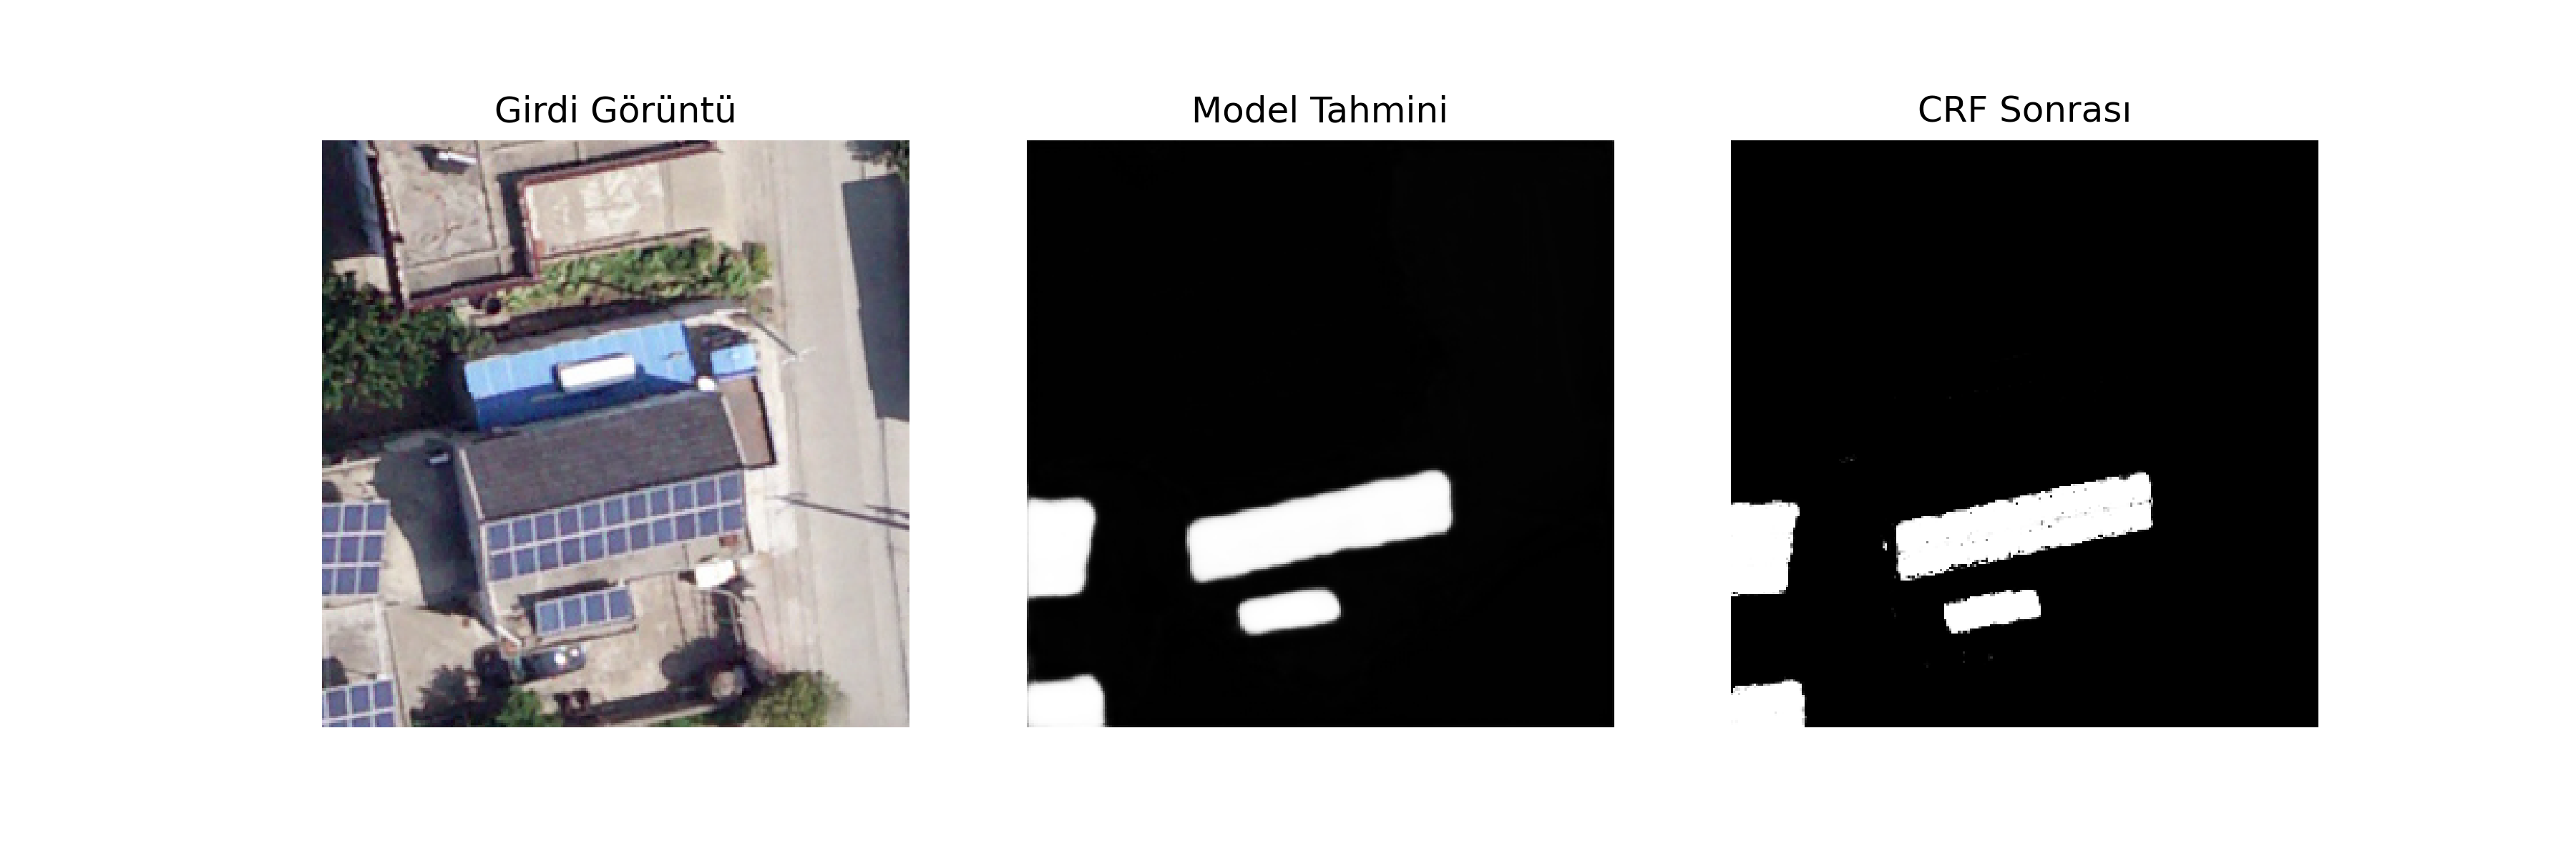

## 29. Alternatif Torchvision Tabanlı Çıkarım

`torchvision.transforms` kullanarak manuel ön işleme yapılan alternatif çıkarım. Ayrı bir görüntü üzerinde modeli hızlıca test etmek için kullanışlıdır.

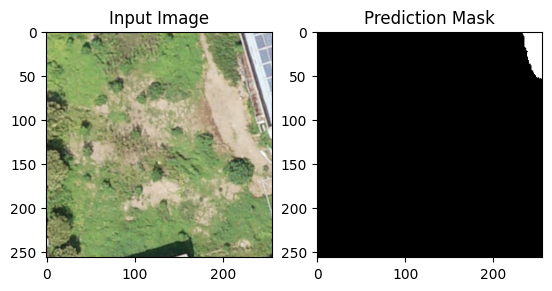

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Görüntüyü yükle
img_path = "/content/drive/MyDrive/GES_veriseti/PV01_Rooftop_Brick/test_görüntüleri/PV01_Rooftop_FlatConcrete/images/PV01_325137_1204224.bmp"
image = Image.open(img_path).convert("RGB")

# 2. Ön işleme (modelin kullandığına göre değişir)
preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(image)
input_batch = input_tensor.unsqueeze(0)  # batch dimension ekle

# 3. Modeli yükle
model.eval()

with torch.no_grad():
    output = model(input_batch)  # model tahmini

# 4. Çıktıyı işle (örneğin sigmoid ve eşik)
output_probs = torch.sigmoid(output)
pred_mask = output_probs > 0.5

# 5. Görselleştir
plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Prediction Mask")
plt.imshow(pred_mask.squeeze().cpu(), cmap='gray')
plt.show()


# Sonuç ve Değerlendirme

Bu çalışmada, uydu görüntülerinden Güneş Enerji Santrali (GES) tespiti amacıyla Attention U-Net tabanlı bir derin öğrenme modeli geliştirilmiştir. Modelde encoder kısmı olarak ResNet34 kullanılmış ve segmentasyon başarımını artırmak amacıyla dikkat (attention) mekanizması uygulanmıştır.

Model eğitimi sırasında veri artırma (data augmentation), BCE + Dice Loss fonksiyonu, IoU ve Dice metrikleri kullanılmıştır. Ayrıca tahmin sonuçlarını iyileştirmek amacıyla DenseCRF sonrası işleme yöntemi uygulanmıştır.

Elde edilen sonuçlara göre model, GES bölgelerini başarılı bir şekilde tespit edebilmiştir. Özellikle Dice ve IoU skorları modelin segmentasyon performansının yeterli seviyede olduğunu göstermektedir. DenseCRF uygulaması sonrasında sınır bölgelerinde daha düzgün segmentasyon sonuçları elde edilmiştir.

**Çalışmanın güçlü yönleri:**
- Attention mekanizması sayesinde önemli bölgelerin daha iyi öğrenilmesi
- ResNet34 encoder kullanımı ile güçlü özellik çıkarımı
- Veri artırma teknikleri ile model genelleme başarısının artırılması
- DenseCRF ile segmentasyon çıktılarının iyileştirilmesi

**Çalışmanın sınırlılıkları:**
- Küçük veri setlerinde bazı bölgelerde yanlış pozitif sonuçlar oluşabilmektedir
- Karmaşık arka plan yapıları model performansını etkileyebilmektedir

**Gelecekte yapılabilecek geliştirmeler:**
- Daha büyük ve çeşitli veri setleri ile eğitim yapılması
- Transformer tabanlı segmentasyon modellerinin kullanılması
- Farklı encoder yapılarının denenmesi
- Hyperparameter optimizasyonu uygulanması
- Gerçek zamanlı GES tespit sistemine dönüştürülmesi

Sonuç olarak geliştirilen model, uydu görüntülerinden GES tespiti probleminde başarılı sonuçlar vermiş ve derin öğrenme tabanlı segmentasyon yöntemlerinin bu alanda etkili olduğunu göstermiştir.